#Базовый пайплайн для проверки модели апскейлинга

###Загрузка модели

In [ ]:
!pip install -U diffusers transformers accelerate safetensors

In [3]:
import torch
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

from diffusers import StableDiffusionUpscalePipeline

In [4]:
model_id = "stabilityai/stable-diffusion-x4-upscaler"

pipe = StableDiffusionUpscalePipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/485 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

###Загрузка изображения

In [11]:
from google.colab import files

uploaded = files.upload()

Saving IMG_8360 (1).JPG to IMG_8360 (1).JPG


In [12]:
image = Image.open("IMG_8360 (1).JPG").convert("RGB")

In [13]:
print(image.size)

(1200, 1200)


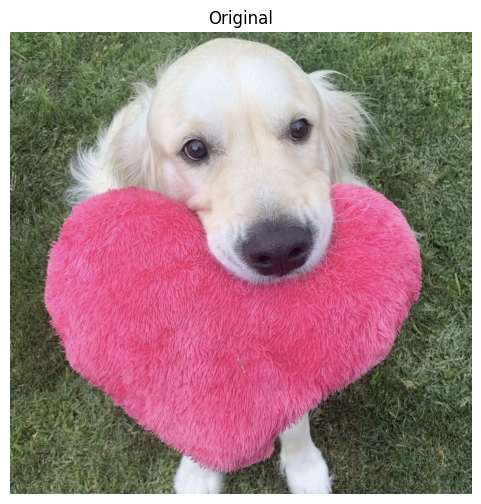

In [14]:
plt.figure(figsize=(6, 6))

plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.show()

###Ухудшение качества изображения

In [25]:
low_res = image.resize((120, 120), Image.Resampling.LANCZOS)

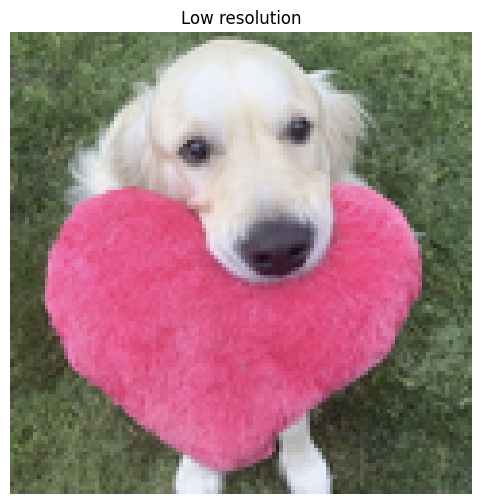

In [26]:
plt.figure(figsize=(6, 6))

plt.imshow(low_res)
plt.axis("off")
plt.title("Low resolution")

plt.show()

###Написание промпта

In [27]:
prompt = "a high quality photo of a dog holding a heart plushie in the mouth"

###Запуск модели на данных

In [28]:
upscaled = pipe(
    prompt=prompt,
    image=low_res
).images[0]

print(upscaled.size)

  0%|          | 0/75 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


(480, 480)


In [29]:
print("Original:", image.size)
print("Low resolution:", low_res.size)
print("Upscaled:", upscaled.size)

Original: (1200, 1200)
Low resolution: (120, 120)
Upscaled: (480, 480)


###Вывод результата в сравнении

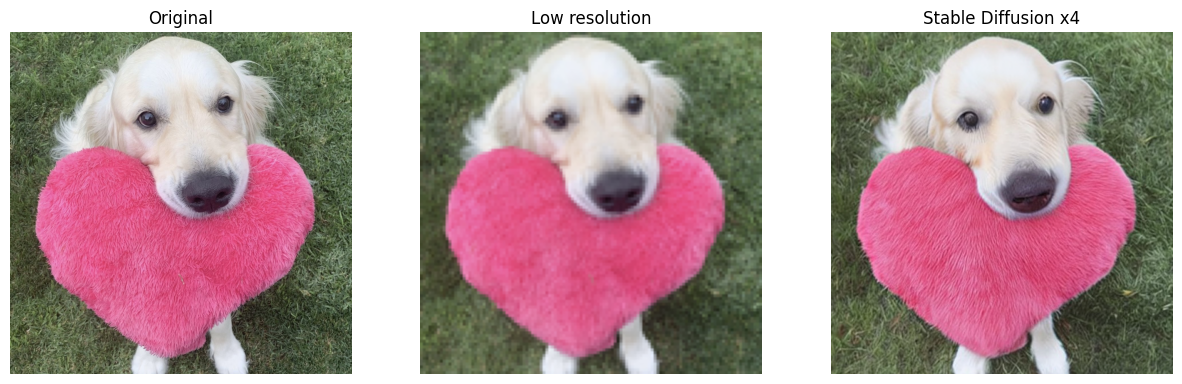

In [30]:
def show_comparison(original, low_res, upscaled):

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(low_res)
    plt.title("Low resolution")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(upscaled)
    plt.title("Stable Diffusion x4")
    plt.axis("off")

    plt.show()

show_comparison(
    image,
    low_res,
    upscaled
)

###Проверка результатов вывода модели на промптах разного качества

In [34]:
prompts = [
    "a photo of a dog",
    "a high quality photo of a dog holding a heart plushie in its mouth",
    "a detailed photograph of a dog holding a messy heart plushie in its mouth, sharp focus",
]

In [35]:
results = []

for prompt in prompts:

    result = pipe(
        prompt=prompt,
        image=low_res
    ).images[0]

    results.append(result)

  0%|          | 0/75 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/75 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/75 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


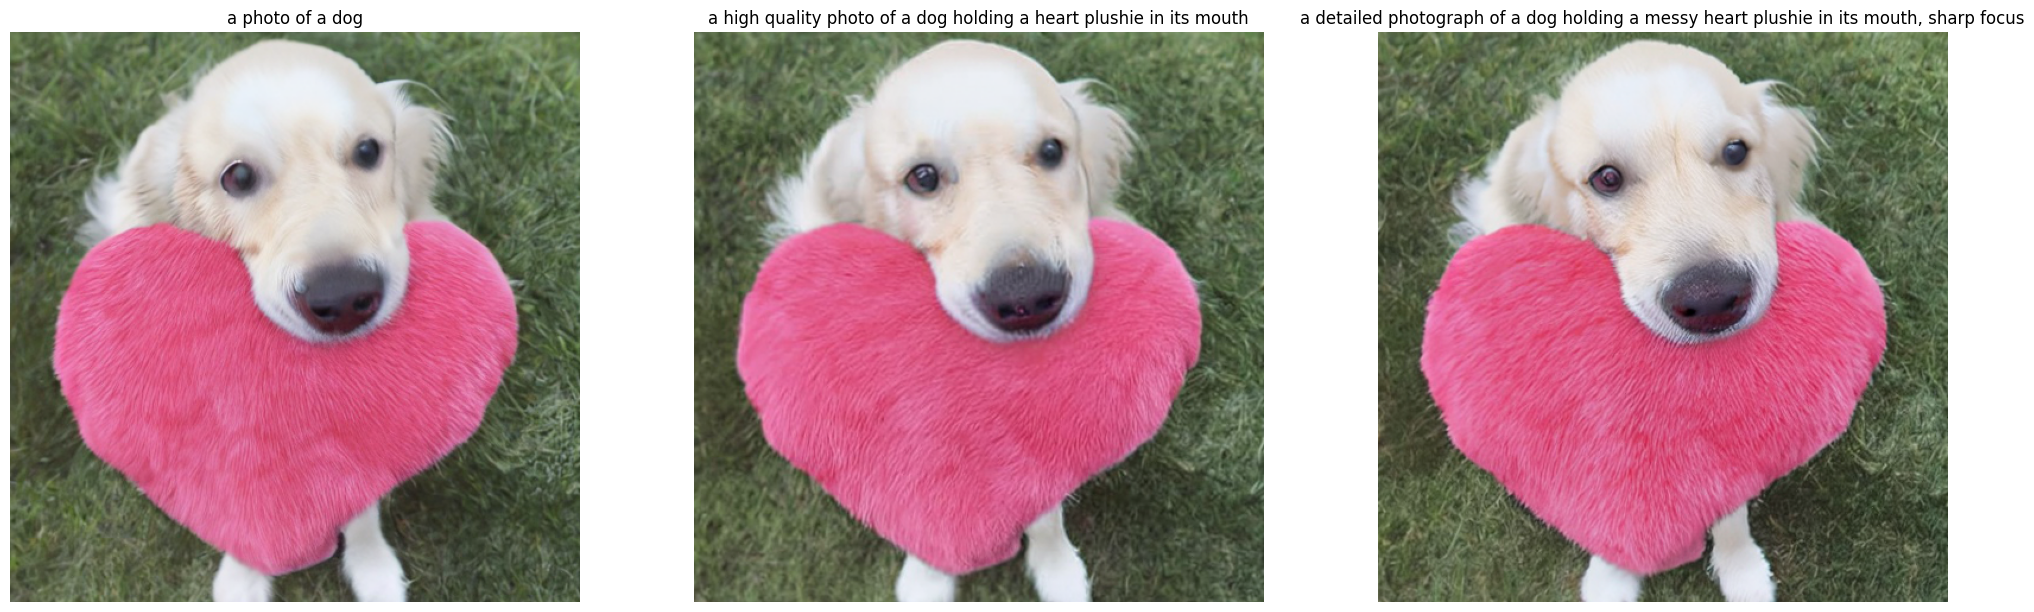

In [41]:
plt.figure(figsize=(25, 20))

for i, result in enumerate(results):

    plt.subplot(1, 3, i + 1)
    plt.imshow(result)
    plt.title(prompts[i])
    plt.axis("off")

plt.show()